Get fort st john and for nelson as an individual shapefile from BC_Fire_Zones

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [5]:
zones = gpd.read_file("../data/raw/BC_Fire_Zones/DRP_MOF_FIRE_ZONES_SP/DRPMFFRZNS_polygon.shp")
zones.head()

,MFFRZND,MFFRCNTRNM,MFFRZNNM,HDQRTRSCTN,OBJECTID,AREA_SQM,FEAT_LEN,geometry
0,481.0,Southeast Fire Centre,Boundary Fire Zone,Grand Forks,1092.0,6.590044e+09,4.570555e+05,"POLYGON ((1546511.208 573564.331, 1546535.69 5..."
1,482.0,Coastal Fire Centre,Fraser Fire Zone,Abbotsford,1093.0,5.844112e+10,2.029064e+06,"MULTIPOLYGON (((1328500.428 580935.612, 132850..."
2,483.0,Kamloops Fire Centre,Penticton Fire Zone,Penticton,1094.0,9.302814e+09,7.757480e+05,"POLYGON ((1446486.499 596234.188, 1446829.502 ..."
3,484.0,Kamloops Fire Centre,Merritt Fire Zone,Merritt,1095.0,1.118309e+10,9.195318e+05,"POLYGON ((1334605.151 622571.845, 1334605.872 ..."
4,485.0,Coastal Fire Centre,Pemberton Fire Zone,Pemberton,1096.0,1.098514e+10,1.024656e+06,"POLYGON ((1159178.165 649935.849, 1159228.927 ..."


In [6]:
# get all unique names in MFFRZNNM column
zones["MFFRZNNM"].unique()

<ArrowStringArray>
[              'Boundary Fire Zone',                 'Fraser Fire Zone',
              'Penticton Fire Zone',                'Merritt Fire Zone',
              'Pemberton Fire Zone',              'Cranbrook Fire Zone',
         'Sunshine Coast Fire Zone',               'Lillooet Fire Zone',
          'Kootenay Lake Fire Zone',                  'Arrow Fire Zone',
              'Invermere Fire Zone',                 'Vernon Fire Zone',
         '100 Mile House Fire Zone',               'Columbia Fire Zone',
               'Kamloops Fire Zone',              'Chilcotin Fire Zone',
 'North Island Mid Coast Fire Zone',                'Quesnel Fire Zone',
          'Robson Valley Fire Zone',          'Prince George Fire Zone',
                 'Nadina Fire Zone',                'Bulkley Fire Zone',
           'Dawson Creek Fire Zone',                 'Skeena Fire Zone',
                 'VanJam Fire Zone',              'Mackenzie Fire Zone',
          'Fort St. John Fire Zo

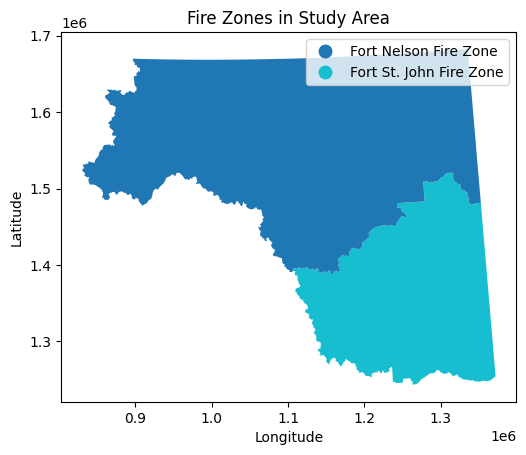

In [9]:
# subset zones to just get Fort Nelson Fire Zone and Fort St. John Fire Zone
study_zones = zones[(zones["MFFRZNNM"] == "Fort Nelson Fire Zone") | (zones["MFFRZNNM"] == "Fort St. John Fire Zone")]
study_zones.plot(column="MFFRZNNM", legend=True)
plt.title("Fire Zones in Study Area")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [10]:
# save to ../data/study_aoi/study_firezones.shp
study_zones.to_file("../data/study_aoi/study_firezones.shp")

In [12]:
# get study area bounding box
study_bbox = study_zones.total_bounds
print(study_bbox)

[ 830257.7731 1242887.8786 1371593.5304 1682799.0614]


crop the lightnight netcdf file to just the study area


In [22]:
# crop lightning netcdf file to just the study area, using just cloud-to-ground
import xarray as xr
xr.set_options(netcdf_engine_order=["netcdf4", "h5netcdf", "scipy"])

try:
    cg_2024 = xr.open_dataset("../data/raw/lightning/cg_flashes_3hr_0.1-deg_2024.nc", engine="netcdf4")
except Exception as e:
    raise RuntimeError("Failed to open netCDF with netCDF4 engine: " + str(e))

cg_2024

<xarray.Dataset> Size: 4GB
Dimensions:     (time: 2928, bnds: 2, lat: 350, lon: 950)
Coordinates:
  * time        (time) datetime64[ns] 23kB 2024-01-01 ... 2024-12-31T21:00:00
  * lat         (lat) float64 3kB 74.95 74.85 74.75 74.65 ... 40.25 40.15 40.05
  * lon         (lon) float64 8kB -144.9 -144.8 -144.8 ... -50.25 -50.15 -50.05
Dimensions without coordinates: bnds
Data variables:
    time_bnds   (time, bnds) datetime64[ns] 47kB ...
    cg_flashes  (time, lat, lon) float32 4GB ...

In [23]:
# Vector (GeoDataFrame) — returns CRS objects
vec = {
    "zones_crs": zones.crs,
    "study_zones_crs": study_zones.crs,
    "shapefile_crs": gpd.read_file("../data/study_aoi/study_firezones.shp").crs
}

# xarray Dataset — list variables, global attrs, dataarray attrs, and candidate CRS/grid-mapping vars
vars_list = list(cg_2024.variables)
global_attrs = cg_2024.attrs
dataarray_attrs = cg_2024["cg_flashes"].attrs if "cg_flashes" in cg_2024 else None
candidates = [v for v in vars_list if any(k in v.lower() for k in ("crs", "spatial_ref", "grid_mapping", "crs_wkt"))]
xr_info = {"variables": vars_list, "global_attrs": global_attrs, "dataarray_attrs": dataarray_attrs, "candidates": candidates}

# Optional: use rioxarray to attach/check CRS (install if needed)
# from installPythonPackage tool: installPythonPackage(["rioxarray"])
# then:
# import rioxarray
# da = cg_2023["cg_flashes"]
# da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
# riox_crs = da.rio.crs

vec, xr_info

({'zones_crs': <Projected CRS: EPSG:3005>
  Name: NAD83 / BC Albers
  Axis Info [cartesian]:
  - E[east]: Easting (metre)
  - N[north]: Northing (metre)
  Area of Use:
  - name: Canada - British Columbia.
  - bounds: (-139.04, 48.25, -114.08, 60.01)
  Coordinate Operation:
  - name: British Columbia Albers
  - method: Albers Equal Area
  Datum: North American Datum 1983
  - Ellipsoid: GRS 1980
  - Prime Meridian: Greenwich,
  'study_zones_crs': <Projected CRS: EPSG:3005>
  Name: NAD83 / BC Albers
  Axis Info [cartesian]:
  - E[east]: Easting (metre)
  - N[north]: Northing (metre)
  Area of Use:
  - name: Canada - British Columbia.
  - bounds: (-139.04, 48.25, -114.08, 60.01)
  Coordinate Operation:
  - name: British Columbia Albers
  - method: Albers Equal Area
  Datum: North American Datum 1983
  - Ellipsoid: GRS 1980
  - Prime Meridian: Greenwich,
  'shapefile_crs': <Projected CRS: EPSG:3005>
  Name: NAD83 / BC Albers
  Axis Info [cartesian]:
  - E[east]: Easting (metre)
  - N[north]

In [24]:
# Clip cg_2024 by study_zones (returns DataArray)
import rioxarray
import geopandas as gpd

# ensure study_zones exists and is geometry-only
zones_wgs = study_zones.to_crs("EPSG:4326")

# DataArray
da = cg_2024["cg_flashes"]

# attach spatial dims and CRS (lon/lat)
da = da.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=False)
if da.rio.crs is None:
    da = da.rio.write_crs("EPSG:4326", inplace=False)

# clip (accepts geopandas GeoSeries or list of geometries)
cg_clipped = da.rio.clip(zones_wgs.geometry.values, zones_wgs.crs, drop=True, invert=False)

# optional: convert back to Dataset with same name
cg_clipped_ds = cg_clipped.to_dataset(name="cg_flashes")
cg_clipped_da = cg_clipped  # returned object
cg_clipped_da

<xarray.DataArray 'cg_flashes' (time: 2928, lat: 39, lon: 89)> Size: 41MB
array([[[nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        ...,
...
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]],

       [[nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        ...,
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.],
        [nan, nan, nan, ...,  0.,  0.,  0.]]],
      shape=(2928, 39, 89), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 23kB 2024-01-01 ... 2024-12-31T21:00:00
  * lat          (lat) float64 312B 59.95 59.85 59.75 ... 56.35 56.25 56.15
  * lon          (lon) float64 712B -128.8 -128.8 -128.6 ... -120.1 -120.0
    spatial_ref  int64 8B 0
Attributes:
    long_name:  frequency_of_cg_lightning_flashes_per_grid_cell_per_hour
    units:      frequency_of_cg_lightning_flashes_per_grid_cell_per_3hours

In [25]:
cg_clipped_da.attrs

{'long_name': 'frequency_of_cg_lightning_flashes_per_grid_cell_per_hour',
 'units': 'frequency_of_cg_lightning_flashes_per_grid_cell_per_3hours'}

In [27]:
cg_clipped_da['time']


<xarray.DataArray 'time' (time: 2928)> Size: 23kB
array(['2024-01-01T00:00:00.000000000', '2024-01-01T03:00:00.000000000',
       '2024-01-01T06:00:00.000000000', ..., '2024-12-31T15:00:00.000000000',
       '2024-12-31T18:00:00.000000000', '2024-12-31T21:00:00.000000000'],
      shape=(2928,), dtype='datetime64[ns]')
Coordinates:
  * time         (time) datetime64[ns] 23kB 2024-01-01 ... 2024-12-31T21:00:00
    spatial_ref  int64 8B 0
Attributes:
    standard_name:  time
    long_name:      time
    bounds:         time_bnds
    axis:           T

In [28]:

cg_clipped_da_subset = cg_clipped_da.sel(
    time=slice("2024-01-01", "2024-06-01")
)


In [29]:

cg_clipped_da_subset.time.min().values, cg_clipped_da_subset.time.max().values

(np.datetime64('2024-01-01T00:00:00.000000000'),
 np.datetime64('2024-06-01T21:00:00.000000000'))

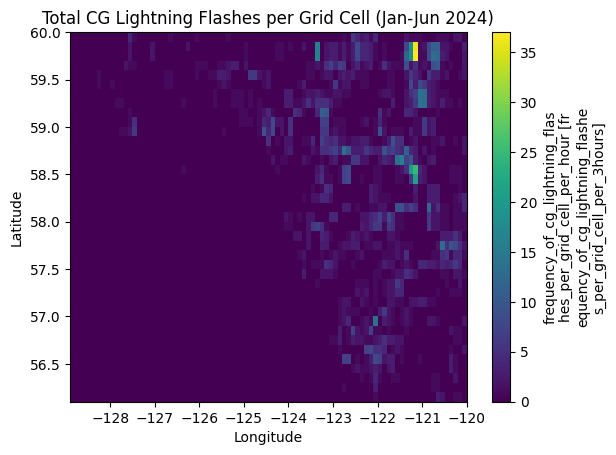

In [30]:
# count the frequency_of_cg_lightning_flashes_per_grid_cell_per_hour in the subsetted, clipped DataArray so it can be plotted as a 2D map within the study area
cg_clipped_da_subset_sum = cg_clipped_da_subset.sum(dim="time")
cg_clipped_da_subset_sum.plot()
plt.title("Total CG Lightning Flashes per Grid Cell (Jan-Jun 2024)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

<Figure size 1000x1000 with 0 Axes>

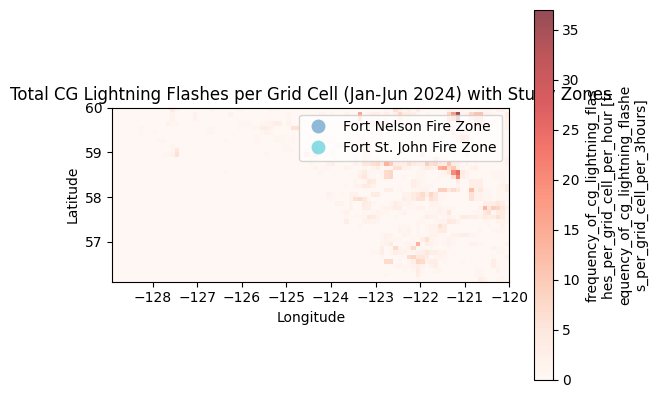

In [34]:
#plot this over the study zones plot made earlier, change colour bar label name to flashes per grid hour (assuming the original data is in flashes per grid hour)
plt.figure(figsize=(10, 10))
study_zones.plot(column="MFFRZNNM", legend=True, alpha=0.5)
cg_clipped_da_subset_sum.plot(ax=plt.gca(), cmap="Reds", alpha=0.7)
plt.title("Total CG Lightning Flashes per Grid Cell (Jan-Jun 2024) with Study Zones")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [31]:
# find the first time step with a non-zero value in the subsetted, clipped DataArray
first_nonzero_time = cg_clipped_da_subset.where(cg_clipped_da_subset > 0).dropna(dim="time", how="all").time.min().values
first_nonzero_time

np.datetime64('2024-04-03T00:00:00.000000000')

In [46]:
import xarray as xr
import numpy as np

da = cg_clipped_da_subset  # (time, lat, lon)

time_da = xr.DataArray(da.time.values.astype("datetime64[ns]"),
                       coords={"time": da.time}, dims=["time"])
first_time_per_cell = time_da.where(da > 0).min(dim="time")  # dtype datetime64[ns]

In [49]:
mask = da > 0
has_any = mask.any(dim="time")
idx = mask.argmax(dim="time")               # index of first True (if any)
first_time_per_cell = da["time"].isel(time=idx).where(has_any)

In [50]:
first_time_per_cell

<xarray.DataArray 'time' (lat: 39, lon: 89)> Size: 28kB
array([[                          'NaT',                           'NaT',
                                  'NaT', ...,
        '2024-05-28T00:00:00.000000000', '2024-05-28T00:00:00.000000000',
                                  'NaT'],
       [                          'NaT',                           'NaT',
                                  'NaT', ...,
                                  'NaT',                           'NaT',
        '2024-05-28T00:00:00.000000000'],
       [                          'NaT',                           'NaT',
                                  'NaT', ...,
                                  'NaT',                           'NaT',
        '2024-05-28T00:00:00.000000000'],
       ...,
       [                          'NaT',                           'NaT',
                                  'NaT', ...,
        '2024-05-30T00:00:00.000000000',                           'NaT',
                                  'NaT'],
       [                          'NaT',                           'NaT',
                                  'NaT', ...,
                                  'NaT',                           'NaT',
                                  'NaT'],
       [                          'NaT',                           'NaT',
                                  'NaT', ...,
        '2024-05-29T21:00:00.000000000', '2024-05-29T21:00:00.000000000',
                                  'NaT']],
      shape=(39, 89), dtype='datetime64[ns]')
Coordinates:
  * lat          (lat) float64 312B 59.95 59.85 59.75 ... 56.35 56.25 56.15
  * lon          (lon) float64 712B -128.8 -128.8 -128.6 ... -120.1 -120.0
    time         (lat, lon) datetime64[ns] 28kB 2024-01-01 ... 2024-01-01
    spatial_ref  int64 8B 0
Attributes:
    standard_name:  time
    long_name:      time
    bounds:         time_bnds
    axis:           T

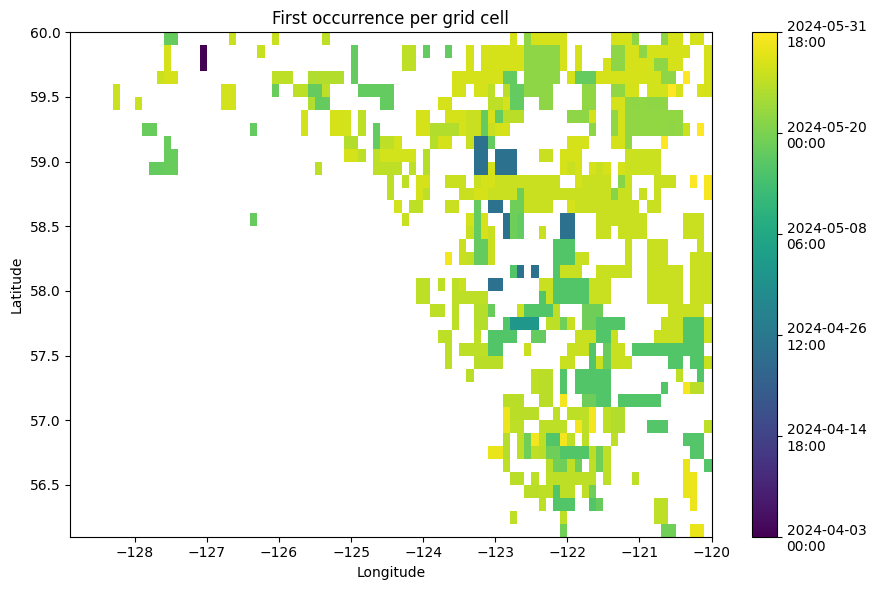

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

ft = first_time_per_cell  # datetime64[ns] 2D DataArray
ft_int = ft.values.astype("datetime64[ns]").astype("int64").astype("float64")
ft_int[np.isnat(ft.values)] = np.nan

lon = ft["lon"].values
lat = ft["lat"].values

fig, ax = plt.subplots(figsize=(9,6))
pcm = ax.pcolormesh(lon, lat, ft_int, shading="auto", cmap="viridis")
cbar = fig.colorbar(pcm, ax=ax)
if not np.isnan(ft_int).all():
    ticks = np.linspace(np.nanmin(ft_int), np.nanmax(ft_int), 6)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(pd.to_datetime(ticks.astype("int64")).strftime("%Y-%m-%d\n%H:%M"))
ax.set_title("First occurrence per grid cell")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

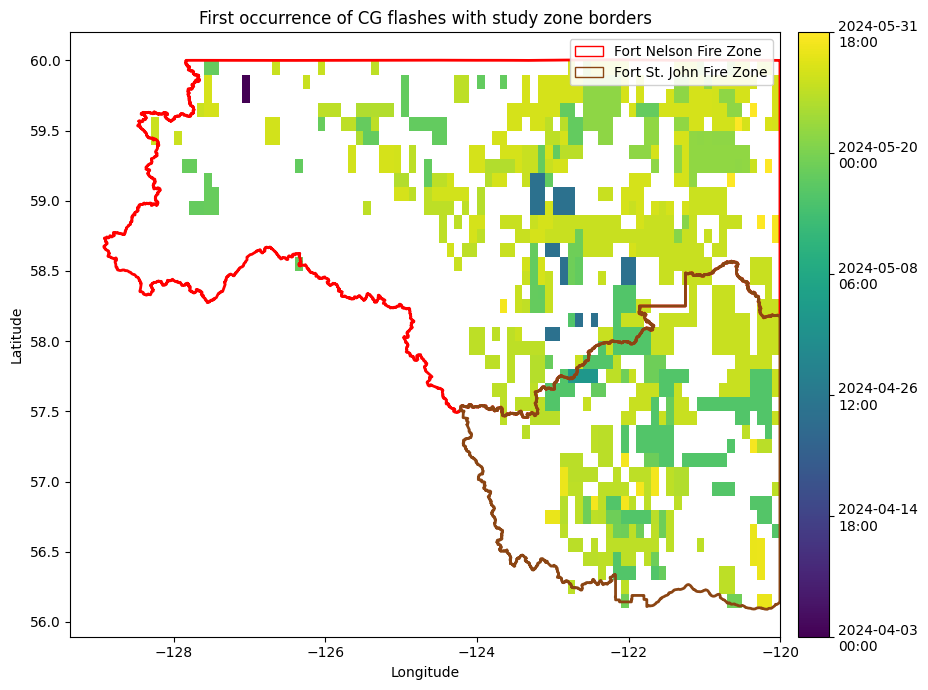

In [53]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ensure raster and zones in lon/lat
zones_wgs = study_zones.to_crs("EPSG:4326")
ft = first_time_per_cell  # must be the 2D datetime64 DataArray
ft_vals = ft.values.astype("datetime64[ns]")
ft_int = ft_vals.astype("int64").astype("float64")
ft_int[np.isnat(ft_vals)] = np.nan
lon = ft["lon"].values
lat = ft["lat"].values

# base plot: raster
fig, ax = plt.subplots(figsize=(10, 7))
pcm = ax.pcolormesh(lon, lat, ft_int, shading="auto", cmap="viridis")
cbar = fig.colorbar(pcm, ax=ax, pad=0.02)
if not np.isnan(ft_int).all():
    ticks = np.linspace(np.nanmin(ft_int), np.nanmax(ft_int), 6)
    cbar.set_ticks(ticks)
    cbar.set_ticklabels(pd.to_datetime(ticks.astype("int64")).strftime("%Y-%m-%d\n%H:%M"))

# plot all zones faintly
zones_wgs.plot(ax=ax, facecolor="none", edgecolor="lightgray", linewidth=1)

# overlay the two zones with specified colors
color_map = {"Fort Nelson Fire Zone": "red", "Fort St. John Fire Zone": "saddlebrown"}
handles = []
for name, color in color_map.items():
    sub = zones_wgs[zones_wgs["MFFRZNNM"] == name]
    if not sub.empty:
        sub.plot(ax=ax, facecolor="none", edgecolor=color, linewidth=2)
        handles.append(Patch(edgecolor=color, facecolor="none", label=name))

# legend (only for the two highlighted zones)
if handles:
    ax.legend(handles=handles, loc="upper right", framealpha=0.9)

ax.set_title("First occurrence of CG flashes with study zone borders")
ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

In [55]:
# save this plot to ../results/first_occurrence_map.png
import os
os.makedirs("../results", exist_ok=True)
fig.savefig("../results/lightning_first_occurrence_map_2024.png", dpi=300)

# lets process the hotspots and plot them on the map

In [60]:
h1 = gpd.read_file("../data/raw/2023-24_Hotspots/DL_FIRE_J1V-C2_666396/fire_archive_J1V-C2_666396.shp")

In [62]:
# get max min ACQ_DATE
acq_date_max = h1["ACQ_DATE"].max()
acq_date_min = h1["ACQ_DATE"].min()
acq_date_max, acq_date_min

(Timestamp('2024-06-01 00:00:00'), Timestamp('2023-10-01 00:00:00'))

In [63]:
# what is the spatial extent of these hotspots?
h1.total_bounds

array([-135.85559,   42.03717,  -54.18784,   69.12431])

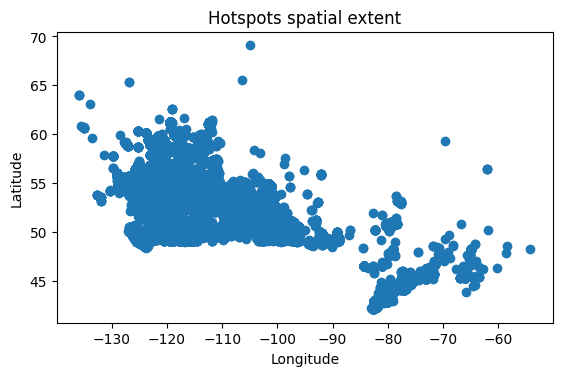

In [64]:
#plot the spatial extent
h1.plot()
plt.title("Hotspots spatial extent")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

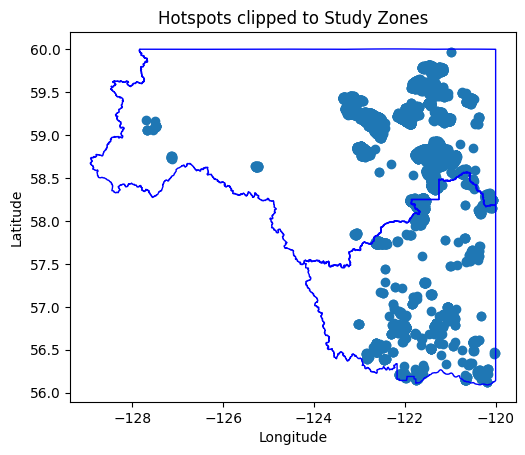

In [65]:
# crop spatial extent to study area zones and plot again
h1_clipped = gpd.clip(h1, zones_wgs)
h1_clipped.plot()
zones_wgs.plot(ax=plt.gca(), facecolor="none", edgecolor="blue", linewidth=1)
plt.title("Hotspots clipped to Study Zones")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

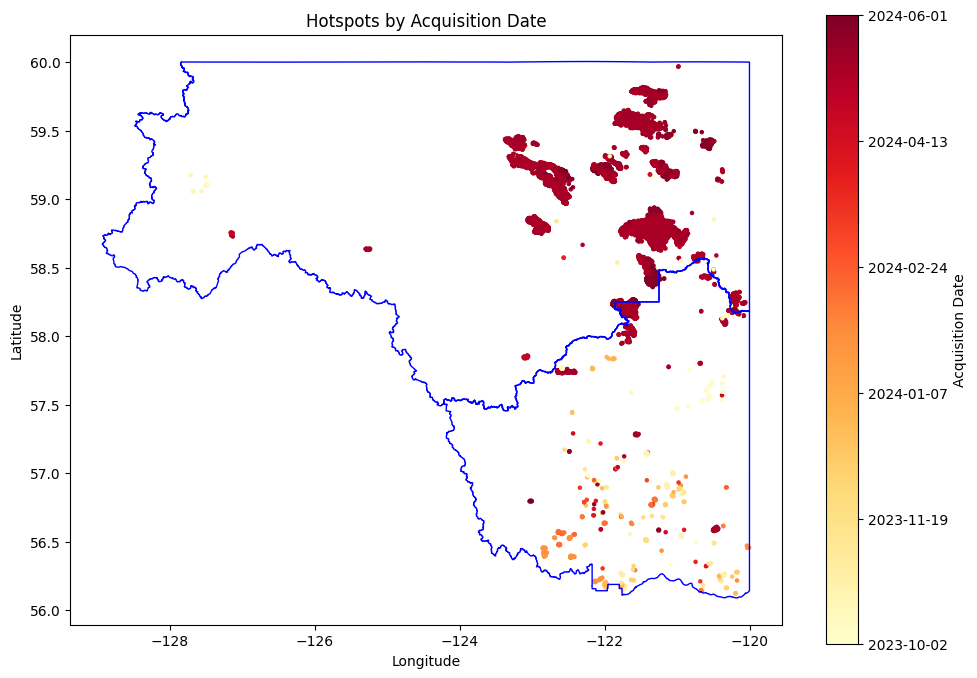

In [67]:
import matplotlib.dates as mdates

# create numeric date column for plotting
h1_clipped = h1_clipped.copy()
h1_clipped["ACQ_DATE_num"] = mdates.date2num(pd.to_datetime(h1_clipped["ACQ_DATE"]))

fig, ax = plt.subplots(figsize=(10, 7))
pcm = h1_clipped.plot(
    column="ACQ_DATE_num",
    ax=ax,
    cmap="YlOrRd",
    legend=False,  # we'll create a custom colorbar
    markersize=5,
)

zones_wgs.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=1)
plt.title("Hotspots by Acquisition Date")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

# add colorbar and format ticks as dates
sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=h1_clipped["ACQ_DATE_num"].min(), vmax=h1_clipped["ACQ_DATE_num"].max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", label="Acquisition Date")
# set date ticks and formatter
ticks = np.linspace(h1_clipped["ACQ_DATE_num"].min(), h1_clipped["ACQ_DATE_num"].max(), 6)
cbar.set_ticks(ticks)
cbar.ax.yaxis.set_major_formatter(mdates.ConciseDateFormatter(mdates.DayLocator()))
cbar.ax.set_yticklabels([mdates.num2date(t).strftime("%Y-%m-%d") for t in ticks])

plt.tight_layout()
plt.show()

In [71]:
# what is the earliest hotspot acquisition date within the study zones for YYYY 2024?
h1_clipped[pd.to_datetime(h1_clipped["ACQ_DATE"]).dt.year == 2024]["ACQ_DATE"].min()


Timestamp('2024-01-01 00:00:00')

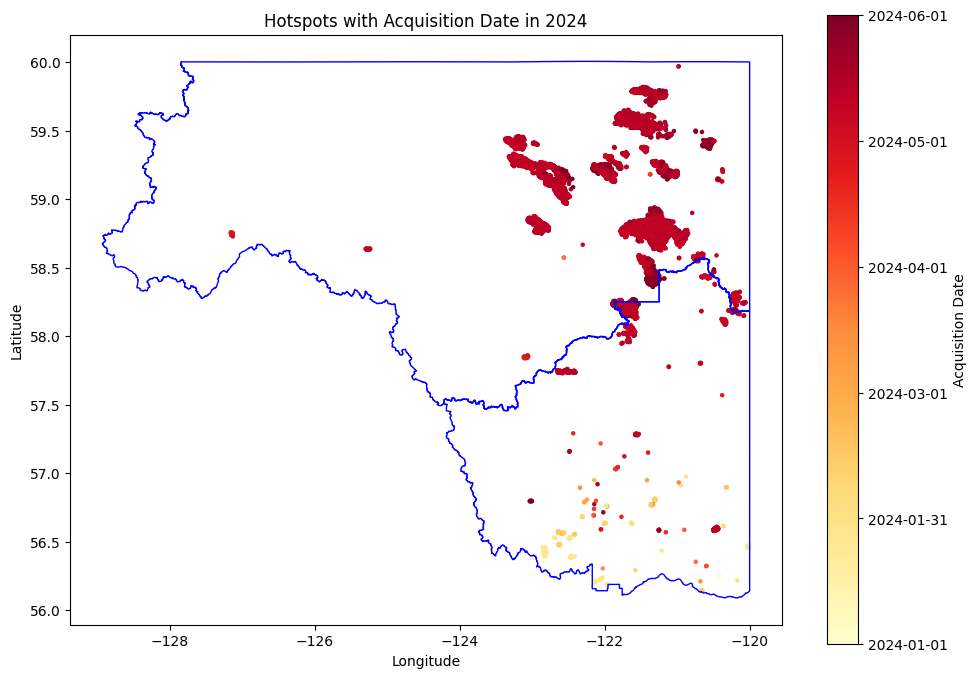

In [72]:
import numpy as np
import matplotlib.dates as mdates

h1_2024 = h1_clipped[pd.to_datetime(h1_clipped["ACQ_DATE"]).dt.year == 2024].copy()
h1_2024["ACQ_DATE_num"] = mdates.date2num(pd.to_datetime(h1_2024["ACQ_DATE"]))

fig, ax = plt.subplots(figsize=(10, 7))
h1_2024.plot(column="ACQ_DATE_num", ax=ax, cmap="YlOrRd", legend=False, markersize=5)
zones_wgs.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=1)
plt.title("Hotspots with Acquisition Date in 2024")
plt.xlabel("Longitude")
plt.ylabel("Latitude")

sm = plt.cm.ScalarMappable(
    cmap="YlOrRd",
    norm=plt.Normalize(vmin=h1_2024["ACQ_DATE_num"].min(), vmax=h1_2024["ACQ_DATE_num"].max()),
)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, orientation="vertical", label="Acquisition Date")

ticks = np.linspace(h1_2024["ACQ_DATE_num"].min(), h1_2024["ACQ_DATE_num"].max(), 6)
cbar.set_ticks(ticks)
cbar.ax.set_yticklabels([mdates.num2date(t).strftime("%Y-%m-%d") for t in ticks])

plt.tight_layout()
plt.show()

count    9483.000000
mean     -379.918064
std       614.394860
min     -5685.000000
25%      -381.000000
50%      -357.000000
75%      -225.000000
max       648.000000
Name: time_diff_hours, dtype: float64


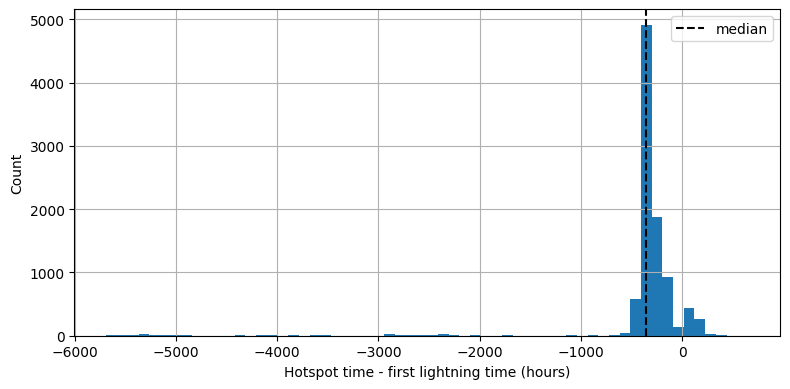

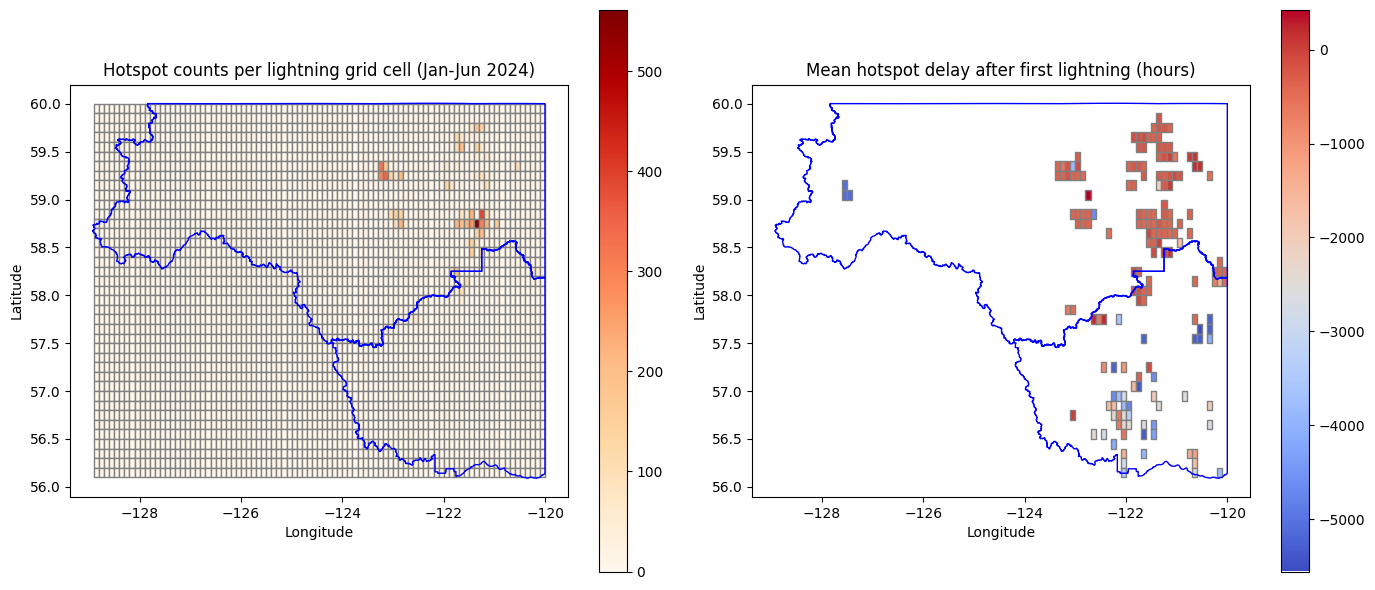

In [74]:
from shapely.geometry import box

# build grid matching first_time_per_cell, join hotspots to grid, compute time differences and plot distribution + map

# prepare grid from DataArray coords
ft = first_time_per_cell  # xarray DataArray (lat, lon) datetime64[ns]
lon = ft["lon"].values
lat = ft["lat"].values
dx = np.mean(np.diff(lon)) if lon.size > 1 else 0.01
dy = np.mean(np.diff(lat)) if lat.size > 1 else 0.01

polys = []
rows = []
for i, y in enumerate(lat):
    for j, x in enumerate(lon):
        geom = box(x - dx/2, y - dy/2, x + dx/2, y + dy/2)
        ft_val = ft.values[i, j]  # may be numpy.datetime64('NaT')
        polys.append(geom)
        rows.append({"lat_idx": i, "lon_idx": j, "first_time": ft_val})

grid_gdf = gpd.GeoDataFrame(rows, geometry=polys, crs="EPSG:4326")

# ensure hotspots in lon/lat and have datetime
hots = h1_clipped.to_crs("EPSG:4326").copy()
hots["acq_time"] = pd.to_datetime(hots["ACQ_DATE"])

# spatial join hotspots -> grid cells
joined = gpd.sjoin(hots, grid_gdf, how="inner", predicate="within")
# drop rows where grid has no first_time
joined = joined[~pd.isna(joined["first_time"])].copy()
joined["first_time"] = pd.to_datetime(joined["first_time"])
joined["time_diff_hours"] = (joined["acq_time"] - joined["first_time"]).dt.total_seconds() / 3600.0

# summary stats
summary = joined["time_diff_hours"].describe()
print(summary)

# histogram of time differences (hours)
plt.figure(figsize=(8,4))
joined["time_diff_hours"].hist(bins=60)
plt.axvline(joined["time_diff_hours"].median(), color="k", linestyle="--", label="median")
plt.xlabel("Hotspot time - first lightning time (hours)")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# aggregate per cell: counts and mean delay, then map
agg = joined.groupby("index_right").agg(count=("geometry","count"), mean_delay_hours=("time_diff_hours","mean"))
grid_stats = grid_gdf.join(agg, how="left")
grid_stats["count"] = grid_stats["count"].fillna(0)

fig, ax = plt.subplots(1,2, figsize=(14,6))
grid_stats.plot(column="count", ax=ax[0], cmap="OrRd", legend=True, edgecolor="gray")
zones_wgs.plot(ax=ax[0], facecolor="none", edgecolor="blue", linewidth=1)
ax[0].set_title("Hotspot counts per lightning grid cell (Jan-Jun 2024)")

grid_stats.plot(column="mean_delay_hours", ax=ax[1], cmap="coolwarm", legend=True, edgecolor="gray")
zones_wgs.plot(ax=ax[1], facecolor="none", edgecolor="blue", linewidth=1)
ax[1].set_title("Mean hotspot delay after first lightning (hours)")

for a in ax:
    a.set_xlabel("Longitude"); a.set_ylabel("Latitude")
plt.tight_layout()
plt.show()


In [76]:
# find hotspots that occured before the first lightning in their cell (negative time_diff_hours) but only in 2024
pre_lightning = joined[(joined["time_diff_hours"] < 0) & (joined["acq_time"].dt.year == 2024)]
print(f"Hotspots that occurred before first lightning in 2024: {len(pre_lightning)}")

Hotspots that occurred before first lightning in 2024: 8607


### NOTE: I need to decide on a time difference between hotspot and lightning, if revisit time = daily, then I would want to find hotspots that happen > 24 hrs at least before a detected lightning strike. Do some analysis by classifying into short, medium, long term windows based on distribution ? like short > 24-72hrs, medium 72 hrs to... 200 and long = 200+? 
- if these are plotted on the landscape, what does it look like? where do they occur? are they close to previous years hotspots (scholten is 1000-m)
- where are they in reference to the previous burn perimeter?

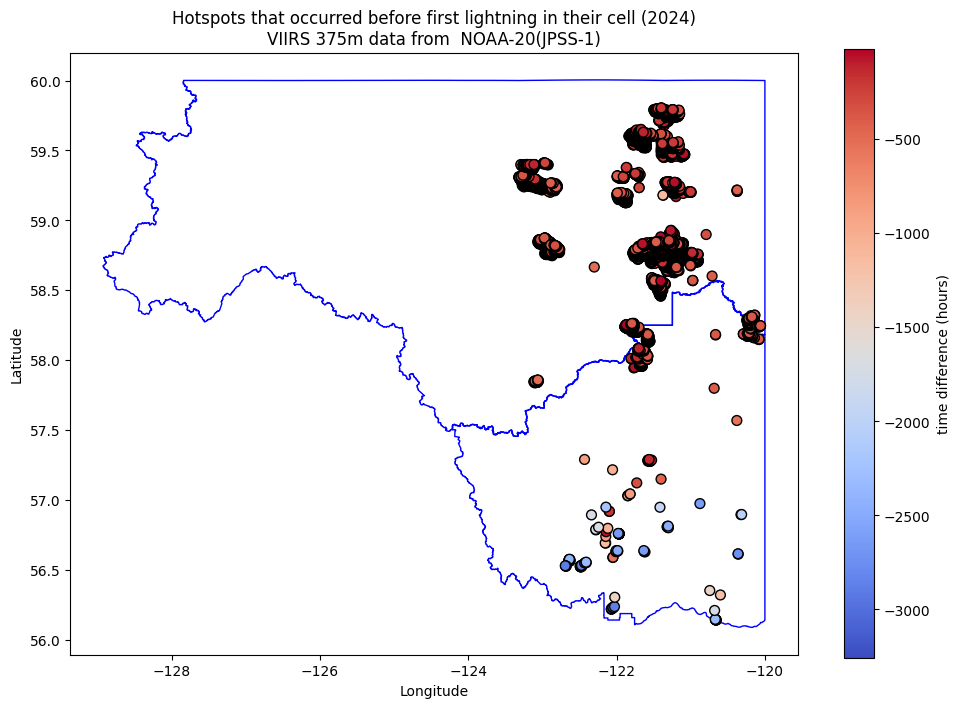

In [83]:
# visualize these pre-lightning hotspots
fig, ax = plt.subplots(figsize=(10, 7))
zones_wgs.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=1)
pre_lightning.plot(column="time_diff_hours", ax=ax, cmap="coolwarm", legend=False, markersize=50, edgecolor="k")
sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=plt.Normalize(vmin=pre_lightning["time_diff_hours"].min(), vmax=pre_lightning["time_diff_hours"].max()))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, label="time difference (hours)")
plt.title("Hotspots that occurred before first lightning in their cell (2024)\nVIIRS 375m data from  NOAA-20(JPSS-1)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.tight_layout()
plt.show()

In [84]:
# save plot
fig.savefig("../results/J1V_pre_lightning_hotspots_2024_2-5kmx2-5km_grid.png", dpi=300)

# Explore Fire perimeters in 2023 and 2024

In [86]:
hist_perims = gpd.read_file("../data/raw/BC_Fire_Perimeters_Historical/PROT_HISTORICAL_FIRE_POLYS_SP/H_FIRE_PLY_polygon.shp")
hist_perims.head()

,FIRE_NO,VERSION_NO,FIRE_YEAR,FIRE_CAUSE,FIRELABEL,SIZE_HA,SOURCE,TRACK_DATE,LOAD_DATE,FIRE_DATE,METHOD,FCODE,SHAPE,OBJECTID,AREA_SQM,FEAT_LEN,geometry
0,106a,NaN,1919,Person,1919-106a,1499.4,linens,NaN,20070517,19190827,digitised,JA70003000,NaN,3157179.0,1.499405e+07,18638.1350,"POLYGON ((1292886.479 709091.085, 1292874.706 ..."
1,107,NaN,1919,Lightning,1919-107,597.8,linens,NaN,20070517,19190816,digitised,JA70003000,NaN,3157180.0,5.978017e+06,11378.2063,"POLYGON ((1788750.382 573069.167, 1788677.581 ..."
2,109,NaN,1919,Lightning,1919-109,55.6,linens,NaN,20070517,19190908,assumed_shape,JA70003000,NaN,3157181.0,5.568185e+05,2712.1349,"POLYGON ((1745078.246 503384.094, 1745018.542 ..."
3,11,NaN,1919,Person,1919-11,67.6,linens,NaN,20070517,19190617,digitised,JA70003000,NaN,3157182.0,6.760848e+05,3021.7439,"POLYGON ((1345117.365 715590.867, 1345244.517 ..."
4,110,NaN,1919,Person,1919-110,659.4,linens,NaN,20070517,19190818,digitised,JA70003000,NaN,3157183.0,6.594344e+06,12552.2741,"POLYGON ((1716545.92 501602.177, 1716559.615 5..."


In [88]:
hist_perims.crs

<Projected CRS: EPSG:3005>
Name: NAD83 / BC Albers
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Canada - British Columbia.
- bounds: (-139.04, 48.25, -114.08, 60.01)
Coordinate Operation:
- name: British Columbia Albers
- method: Albers Equal Area
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [89]:
zones_wgs.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [91]:
# filter fire year to 2023 and 2024 and only get firest within the study zones
hist_perims["FIRE_YEAR"] = pd.to_numeric(hist_perims["FIRE_YEAR"], errors="coerce")

# ensure both layers use BC Albers (EPSG:3005) before clipping
target_crs = "EPSG:3005"
if hist_perims.crs is None:
    hist_perims = hist_perims.set_crs(target_crs)
else:
    hist_perims = hist_perims.to_crs(target_crs)

zones_3005 = zones_wgs.to_crs(target_crs)

hist_perims_clipped = gpd.clip(hist_perims, zones_3005)
hist_perims_clipped_2023_2024 = hist_perims_clipped[hist_perims_clipped["FIRE_YEAR"].isin([2023, 2024])]
hist_perims_clipped_2023_2024.head()

,FIRE_NO,VERSION_NO,FIRE_YEAR,FIRE_CAUSE,FIRELABEL,SIZE_HA,SOURCE,TRACK_DATE,LOAD_DATE,FIRE_DATE,METHOD,FCODE,SHAPE,OBJECTID,AREA_SQM,FEAT_LEN,geometry
24173,G81281,2.024080e+09,2024,Lightning,2024-G81281,33.3,2024 ROLLOVER,20240804,20240804,20240719,Hand sketch of any type,JA70003000,NaN,3181322.0,3.326329e+05,3836.1039,"POLYGON ((1187062.57 1282141.858, 1187060.463 ..."
23505,G80419,2.024053e+09,2024,Lightning,2024-G80419,71.7,2024 ROLLOVER,20240531,20240601,20240529,Non-corrected airborne GPS,JA70003000,NaN,3181311.0,7.171987e+05,5302.7819,"MULTIPOLYGON (((1181100.08 1315532.019, 118118..."
23920,G90565,2.023061e+09,2023,Lightning,2023-G90565,192.9,2023 ROLLOVER,20230607,20230613,20230602,Digitized from image,JA70003000,NaN,3180770.0,1.928720e+06,6543.4959,"POLYGON ((1122557.492 1439081.254, 1122599.826..."
23939,G90810,2.023101e+09,2023,Lightning,2023-G90810,228.5,2023 ROLLOVER,20231006,20231010,20230609,Derived from satellite imagery,JA70003000,NaN,3180775.0,2.284783e+06,12020.8235,"POLYGON ((1143227.671 1408892.274, 1143176.265..."
24054,G93345,2.023092e+09,2023,Person,2023-G93345,9.7,2023 ROLLOVER,20230923,20230927,20230921,Non-corrected ground GPS,JA70003000,NaN,3180807.0,9.677014e+04,3659.5759,"MULTIPOLYGON (((1156024.405 1410101.853, 11560..."


In [93]:
hist_perims_clipped_2023_2024.shape[0]

142

<positron-console-cell-98>:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


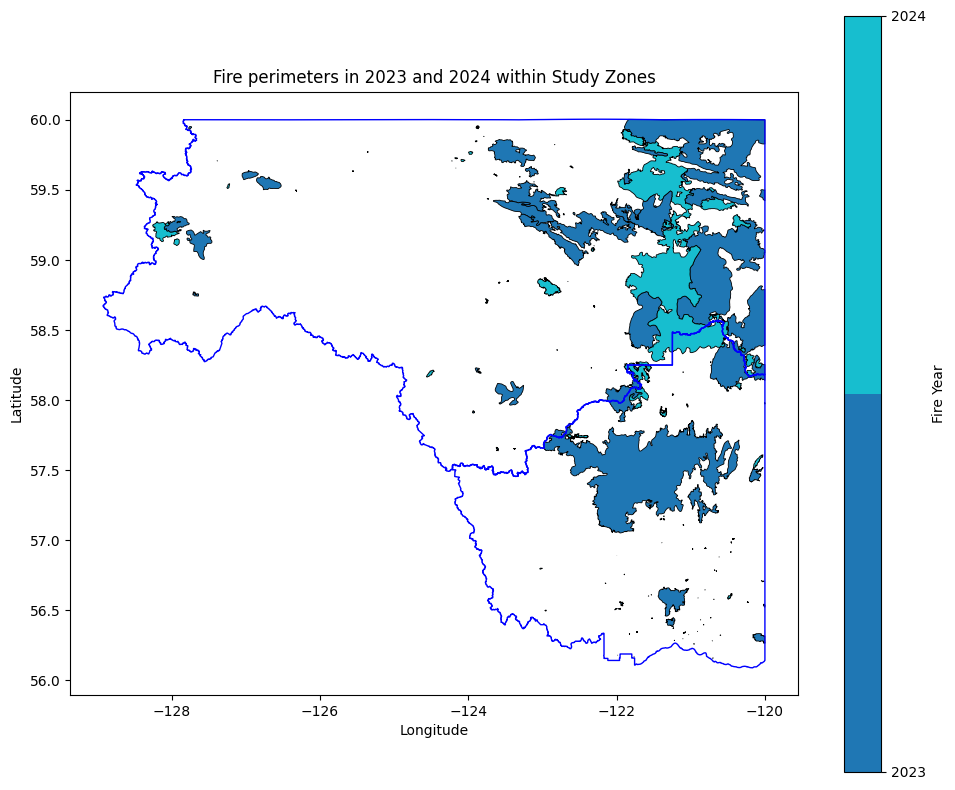

In [98]:
import matplotlib as mpl
import numpy as np

# plot them within the zone but first convert back to WGS84 for plotting
hist_perims_clipped_2023_2024_wgs = hist_perims_clipped_2023_2024.to_crs("EPSG:4326")

gdf = hist_perims_clipped_2023_2024_wgs.copy()
years = sorted(gdf['FIRE_YEAR'].dropna().unique().tolist())

fig, ax = plt.subplots(figsize=(10, 8))
if len(years) == 0:
    gdf.plot(ax=ax, edgecolor="black", linewidth=0.6)
else:
    # map years to integer indices so we can use a discrete colormap and a manual colorbar
    mapdict = {y: i for i, y in enumerate(years)}
    gdf['year_idx'] = gdf['FIRE_YEAR'].map(mapdict)

    cmap = mpl.cm.get_cmap("tab10", len(years))
    lcmap = mpl.colors.ListedColormap([cmap(i) for i in range(len(years))])

    gdf.plot(column='year_idx', ax=ax, cmap=lcmap, legend=False, edgecolor="black", linewidth=0.6)

    sm = mpl.cm.ScalarMappable(cmap=lcmap, norm=mpl.colors.Normalize(vmin=0, vmax=len(years) - 1))
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, ticks=range(len(years)))
    cbar.ax.set_yticklabels([str(y) for y in years])
    cbar.set_label('Fire Year')

zones_wgs.plot(ax=ax, facecolor="none", edgecolor="blue", linewidth=1)
ax.set_title("Fire perimeters in 2023 and 2024 within Study Zones")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.tight_layout()
plt.show()

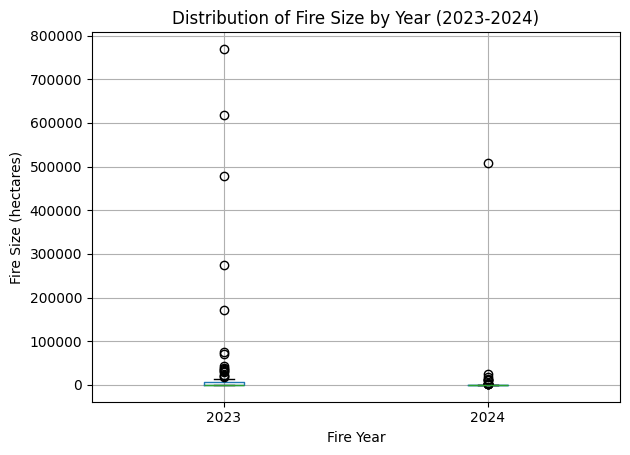

In [100]:
# distribution of FIRE_SIZE for 2023 and 2024 perimeters within the study zones
hist_perims_clipped_2023_2024["SIZE_HA"] = pd.to_numeric(hist_perims_clipped_2023_2024["SIZE_HA"], errors="coerce")
hist_perims_clipped_2023_2024["FIRE_YEAR"] = pd.to_numeric(hist_perims_clipped_2023_2024["FIRE_YEAR"], errors="coerce")
hist_perims_clipped_2023_2024.boxplot(column="SIZE_HA", by="FIRE_YEAR")
plt.title("Distribution of Fire Size by Year (2023-2024)")
plt.suptitle("")
plt.xlabel("Fire Year")
plt.ylabel("Fire Size (hectares)")
plt.tight_layout()
plt.show()